# Thesis

## Install Library

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Import Library

In [2]:
import time
import os
import shutil
import yaml
import os
import dagshub
import mlflow
import torch
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from roboflow import Roboflow
from ultralytics import YOLO, settings

## Download Dataset

### Object Detection Dataset

In [3]:
# Dataset For Object Detection All Class
rf = Roboflow(api_key="MQdx0fMQ8FiQPaS1VHRH")
project = rf.workspace("abiya-thesis").project("plant-pathology-2021-object-detection-j1jvh")
version = project.version(9)
dataset = version.download("yolov11", location="dataset/roboflow/object_detection_all_class")

loading Roboflow workspace...
loading Roboflow project...


In [4]:
# Dataset For Object Detection Frog Eye Leaf Spot Class
rf = Roboflow(api_key="MQdx0fMQ8FiQPaS1VHRH")
project = rf.workspace("abiya-thesis").project("plant-pathology-2021-object-detection-j1jvh")
version = project.version(6)
dataset = version.download("yolov11", location="dataset/roboflow/object_detection_frog_eye_leaf_spot")      

loading Roboflow workspace...
loading Roboflow project...


In [5]:
# Dataset For Object Detection Healthy Class
rf = Roboflow(api_key="MQdx0fMQ8FiQPaS1VHRH")
project = rf.workspace("abiya-thesis").project("plant-pathology-2021-object-detection-j1jvh")
version = project.version(7)
dataset = version.download("yolov11", location="dataset/roboflow/object_detection_healthy_class")

loading Roboflow workspace...
loading Roboflow project...


In [6]:
# Dataset For Object Detection Rust Class
rf = Roboflow(api_key="MQdx0fMQ8FiQPaS1VHRH")
project = rf.workspace("abiya-thesis").project("plant-pathology-2021-object-detection-j1jvh")
version = project.version(8)
dataset = version.download("yolov11", location="dataset/roboflow/object_detection_rust_class")

loading Roboflow workspace...
loading Roboflow project...


### Segmentation Dataset

In [7]:
# Dataset For Segmentation Mask Lesi
rf = Roboflow(api_key="MQdx0fMQ8FiQPaS1VHRH")
project = rf.workspace("abiya-thesis").project("plant-pathology-2021-instance-segmentation-h5pim")
version = project.version(7)
dataset = version.download("yolov11", location="dataset/roboflow/segmentation_mask_lession")

loading Roboflow workspace...
loading Roboflow project...


In [8]:
# Dataset For Segmentation Mask Leaf
rf = Roboflow(api_key="MQdx0fMQ8FiQPaS1VHRH")
project = rf.workspace("abiya-thesis").project("plant-pathology-2021-instance-segmentation-h5pim")
version = project.version(6)
dataset = version.download("yolov11", location="dataset/roboflow/segmentation_mask_leaf")

loading Roboflow workspace...
loading Roboflow project...


## Global Function

In [9]:
# ML Flow dan DagsHub Integration
dagshub.init(repo_owner='abiyamf', repo_name='thesis', mlflow=True)
settings.update({"mlflow": True})

Accessing as abiyamf

Initialized MLflow to track repo "abiyamf/thesis"

Repository abiyamf/thesis initialized!

In [10]:
os.environ["MLFLOW_KEEP_RUN_ACTIVE"] = "True"
time_now = datetime.datetime.now().strftime("%m-%d_%H-%M")
gpu_name = torch.cuda.get_device_name(0)

def format_duration(seconds: float) -> str:
    """Convert seconds into 'Hh Mm Ss' format."""
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return f"{hours}h {minutes}m {secs}s"

def save_class_metrics(val_results, mode):
    # Ambil nama class
    names = val_results.names

    # Data per-class
    data = {
        "class": [names[i] for i in range(len(names))],
        "precision": val_results.box.p.tolist(),
        "recall": val_results.box.r.tolist(),
        "mAP50": val_results.box.ap50.tolist(),
        "mAP50-95": val_results.box.maps.tolist(),
    }

    # Tambahkan baris agregat "all"
    all_row = {
        "class": "all",
        "precision": float(val_results.box.mp),
        "recall": float(val_results.box.mr),
        "mAP50": float(val_results.box.map50),
        "mAP50-95": float(val_results.box.map),
    }

    for key in data.keys():
        data[key].insert(0, all_row[key])

    # Buat DataFrame dan simpan
    df = pd.DataFrame(data)
    csv_path = os.path.join(str(val_results.save_dir), f"class_metrics_{mode}.csv")
    df.to_csv(csv_path, index=False)

    return csv_path

## Training Object Detection All Class

In [15]:
# Variabel Global
predict = False
projectType = "object_detection_all_class"
imgsz = 640
models = ['yolo11n.pt', 'yolo11s.pt', 'yolo11m.pt']
sizes = ['nano', 'small', 'medium']
epochs = 100
batch = 16 # atau -1 untuk limitasi gpu 60%
data_path_objectDetection_all_class = "dataset/roboflow/object_detection_all_class"
project_base_objectDetection_all_class = "results/object_detection_all_class"

In [16]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50": float(validation.box.map50),
            "val mAP50-95": float(validation.box.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

New https://pypi.org/project/ultralytics/8.3.232 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/object_detection_all_class/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, 

In [17]:
if predict:
    for size in sizes:
        print(f"Running prediction for {size} model...")

        model = YOLO(f"results/object_detection/training/{size}/weights/best.pt")

        # Define the output directory for the current model size
        output_dir = f"results/object_detection/predict/{size}"
        os.makedirs(output_dir, exist_ok=True)

        results = model(
            source=f"{project_base_objectDetection_all_class}/test/images", 
            exist_ok=True,
            stream=True
        )

        for i, result in enumerate(results):
            original_filename = os.path.basename(result.path)
            save_path = os.path.join(output_dir, original_filename)
            result.save(filename=save_path)

        print(f"Finished predicting for {size} model.")

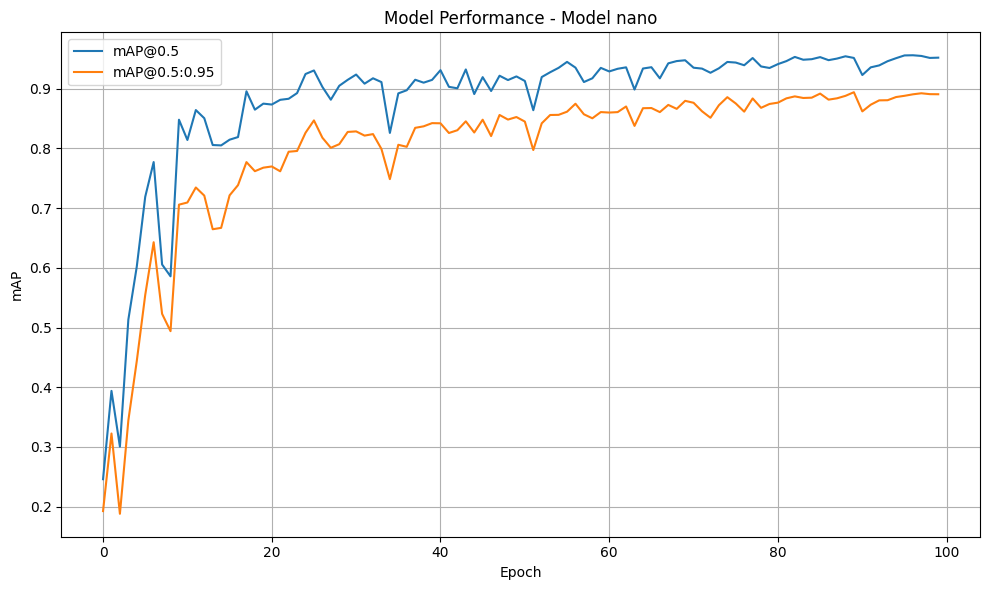

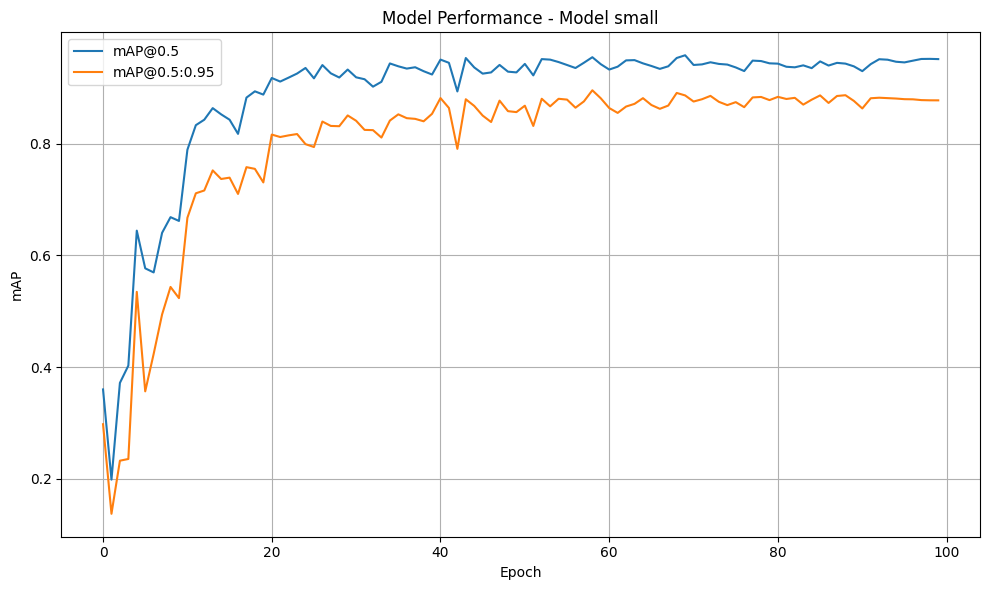

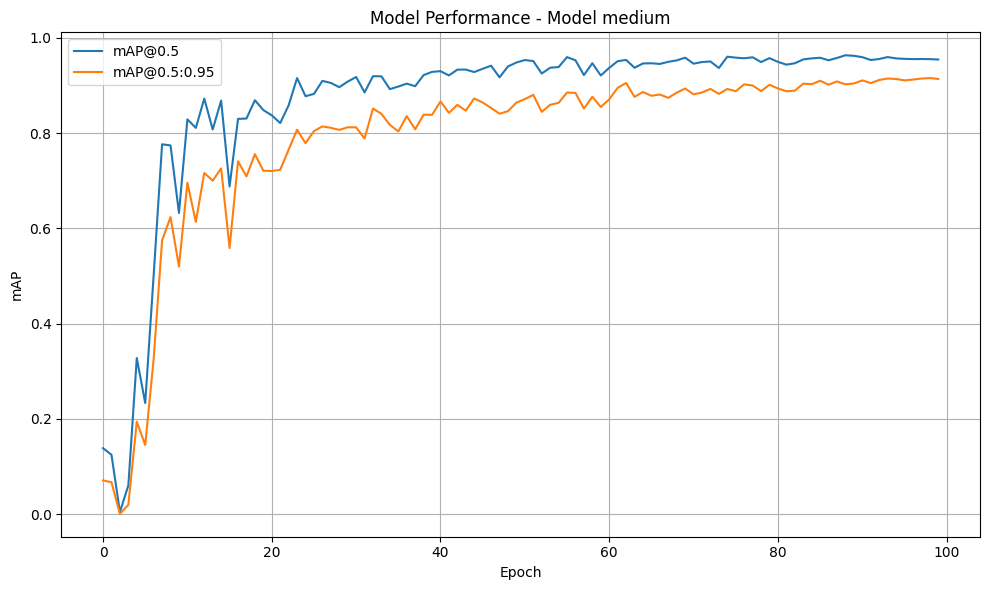

In [18]:
%matplotlib inline
for size in sizes:
    df = pd.read_csv(f"{project_base_objectDetection_all_class}/training/{size}/results.csv")

    plt.figure(figsize=(10, 6))

    # Plot mAP50 dan mAP50-95
    plt.plot(df.index, df["metrics/mAP50(B)"], label="mAP@0.5")
    plt.plot(df.index, df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")

    # Tambahkan label dan judul
    plt.xlabel("Epoch")
    plt.ylabel("mAP")
    plt.title(f"Model Performance - Model {size}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Simpan plot
    graph_output_dir = f"{project_base_objectDetection_all_class}/graph"
    os.makedirs(graph_output_dir, exist_ok=True)
    plt.savefig(os.path.join(graph_output_dir, f"mAP_comparison_{size}.png"))
    # plt.show()

## Training Segmentation Mask Daun

In [19]:
# Variabel Global
predict = False
projectType = "segmentation_mask_leaf"
imgsz = 640
models = ['yolo11n-seg.pt', 'yolo11s-seg.pt', 'yolo11m-seg.pt']
sizes = ['nano', 'small', 'medium']
epochs = 100
batch = 16 # atau -1 untuk limitasi gpu 60%
data_path_segmentation_mask_leaf = "dataset/roboflow/segmentation_mask_leaf"
project_base_segmentation_mask_leaf = f"results/{projectType}"

In [20]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()        
        training = model.train(
            data=f"{data_path_segmentation_mask_leaf}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_segmentation_mask_leaf}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_segmentation_mask_leaf}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_segmentation_mask_leaf}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_segmentation_mask_leaf}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50": float(validation.box.map50),
            "val mAP50-95": float(validation.box.map),
        })

        print(f"Finished training and validating {size} model.")
        
mlflow.end_run()

2025/11/26 00:35:59 INFO mlflow.tracking.fluent: Experiment with name 'thesis-segmentation_mask_leaf' does not exist. Creating a new experiment.


New https://pypi.org/project/ultralytics/8.3.232 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/segmentation_mask_leaf/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, 

2025/11/26 00:36:50 INFO mlflow.tracking.fluent: Experiment with name 'results/segmentation_mask_leaf/training' does not exist. Creating a new experiment.


MLflow: logging run_id(9a111faab1f74d0ab79dcc284891eea8) to https://dagshub.com/abiyamf/thesis.mlflow
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\abiyamf\Documents\Thesis\Plant Pathology 2021 v2\results\segmentation_mask_leaf\training\nano
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size
      1/100      3.02G     0.6813      1.818      2.813      1.147         62        640: 100% ━━━━━━━━━━━━ 33/33 2.9it/s 11.3s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.4it/s 0.9s0.7s
                   all         75        132     0.0058      0.985      0.382      0.297    0.00567      0.971      0.378      0.324

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size
      2/100   

In [21]:
if predict:
    for size in sizes:
        print(f"Running prediction for {size} model...")

        model = YOLO(f"{project_base_segmentation_mask_leaf}/training/{size}/weights/best.pt")

        # Define the output directory for the current model size
        output_dir = f"{project_base_segmentation_mask_leaf}/predict/{size}"
        os.makedirs(output_dir, exist_ok=True)

        results = model(
            source=f"{data_path_segmentation_mask_leaf}/test/images", 
            exist_ok=True,
            stream=True
        )

        for i, result in enumerate(results):
            original_filename = os.path.basename(result.path)
            save_path = os.path.join(output_dir, original_filename)
            result.save(filename=save_path)

        print(f"Finished predicting for {size} model.")

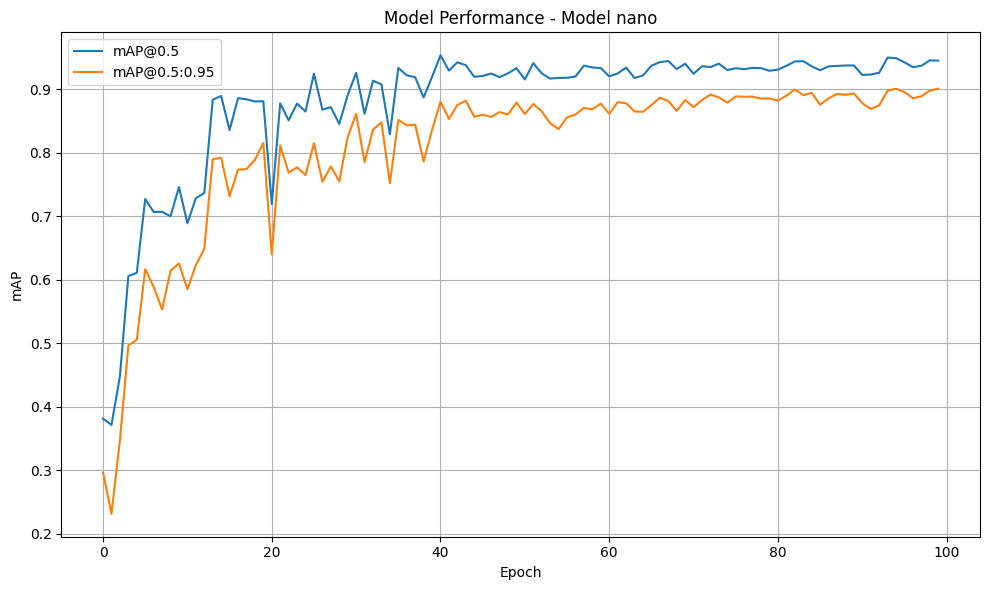

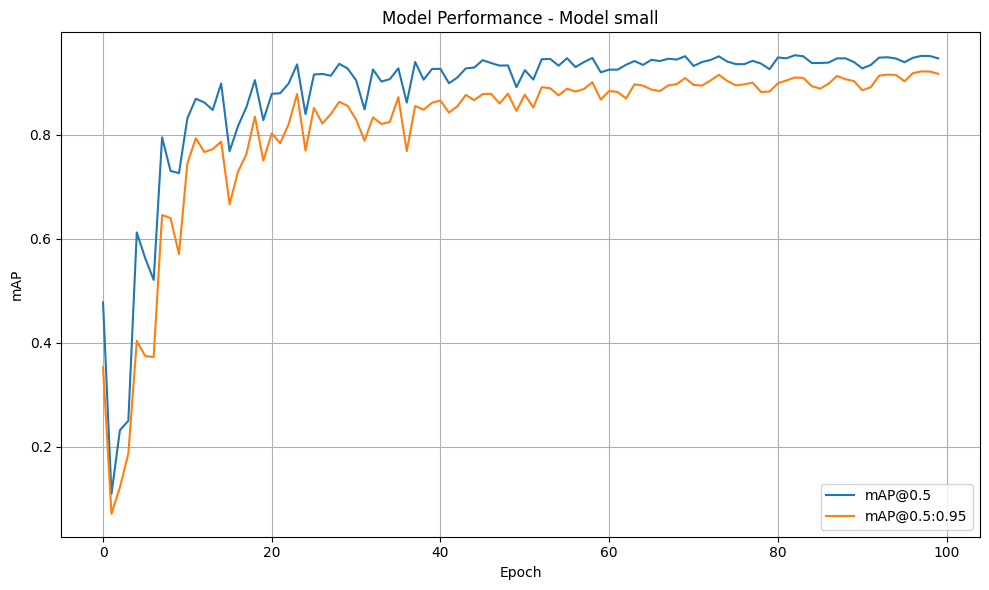

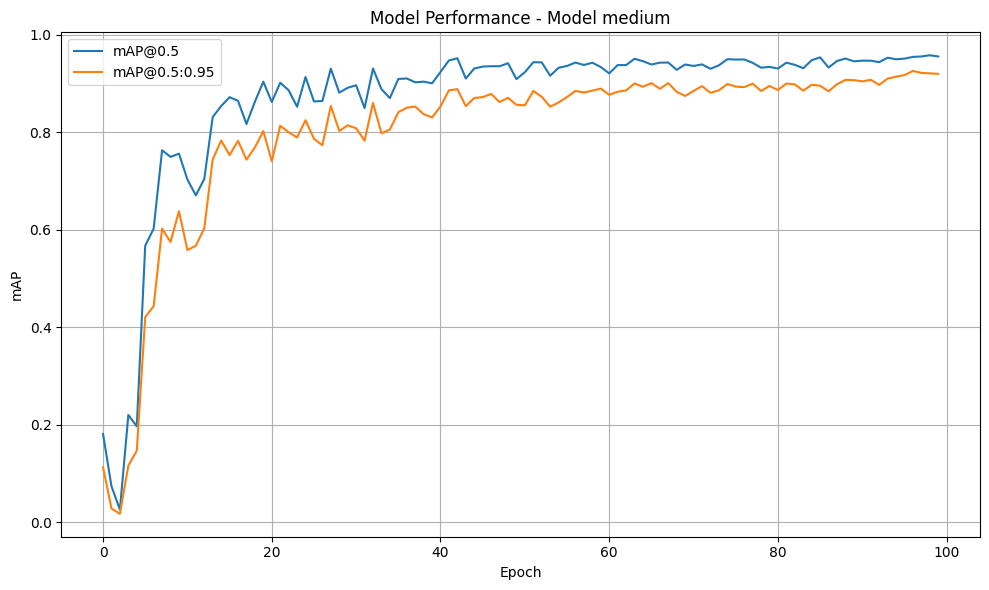

In [22]:
%matplotlib inline
for size in sizes:
    df = pd.read_csv(f"{project_base_segmentation_mask_leaf}/training/{size}/results.csv")

    plt.figure(figsize=(10, 6))

    # Plot mAP50 dan mAP50-95
    plt.plot(df.index, df["metrics/mAP50(B)"], label="mAP@0.5")
    plt.plot(df.index, df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")

    # Tambahkan label dan judul
    plt.xlabel("Epoch")
    plt.ylabel("mAP")
    plt.title(f"Model Performance - Model {size}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Simpan plot
    graph_output_dir = f"{project_base_segmentation_mask_leaf}/graph"
    os.makedirs(graph_output_dir, exist_ok=True)
    plt.savefig(os.path.join(graph_output_dir, f"mAP_comparison_{size}.png"))
    # plt.show()

## Training Segmentation Mask Lesi

In [25]:
# Variabel Global
predict = False
projectType = "segmentation_mask_lession"
imgsz = 640
# models = ['yolo11n-seg.pt', 'yolo11s-seg.pt', 'yolo11m-seg.pt']
# sizes = ['nano', 'small', 'medium']
models = ['yolo11s-seg.pt', 'yolo11m-seg.pt']
sizes = ['small', 'medium']
epochs = 100
batch = 16 # atau -1 untuk limitasi gpu 60%
data_path_segmentation_mask_lession = "dataset/roboflow/segmentation_mask_lession"
project_base_segmentation_mask_lession = f"results/{projectType}"

In [26]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()         
        training = model.train(
            data=f"{data_path_segmentation_mask_lession}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_segmentation_mask_lession}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_segmentation_mask_lession}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_segmentation_mask_lession}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_segmentation_mask_lession}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50": float(validation.box.map50),
            "val mAP50-95": float(validation.box.map),
        })            

        print(f"Finished training and validating {size} model.")
mlflow.end_run()

New https://pypi.org/project/ultralytics/8.3.232 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/segmentation_mask_lession/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=Fals

In [27]:
if predict:
    for size in sizes:
        print(f"Running prediction for {size} model...")

        model = YOLO(f"{project_base_segmentation_mask_lession}/training/{size}/weights/best.pt")

        # Define the output directory for the current model size
        output_dir = f"{project_base_segmentation_mask_lession}/predict/{size}"
        os.makedirs(output_dir, exist_ok=True)

        results = model(
            source=f"{data_path_segmentation_mask_lession}/test/images", # Kedepannya ubah menjadi /test jika sudah ada test yang di anotasi
            exist_ok=True,
            stream=True
        )

        for i, result in enumerate(results):
            original_filename = os.path.basename(result.path)
            save_path = os.path.join(output_dir, original_filename)
            result.save(filename=save_path)

        print(f"Finished predicting for {size} model.")

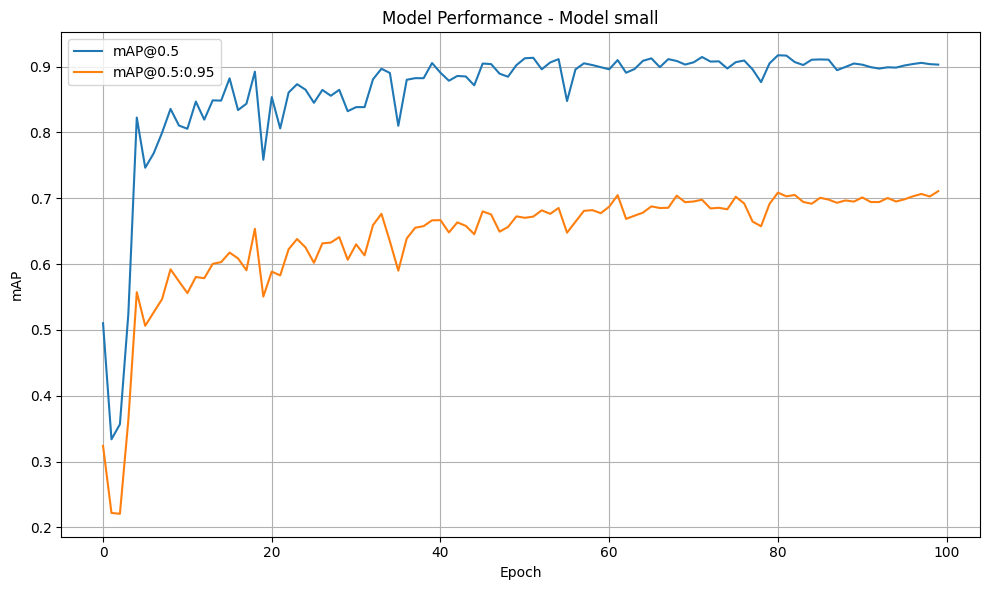

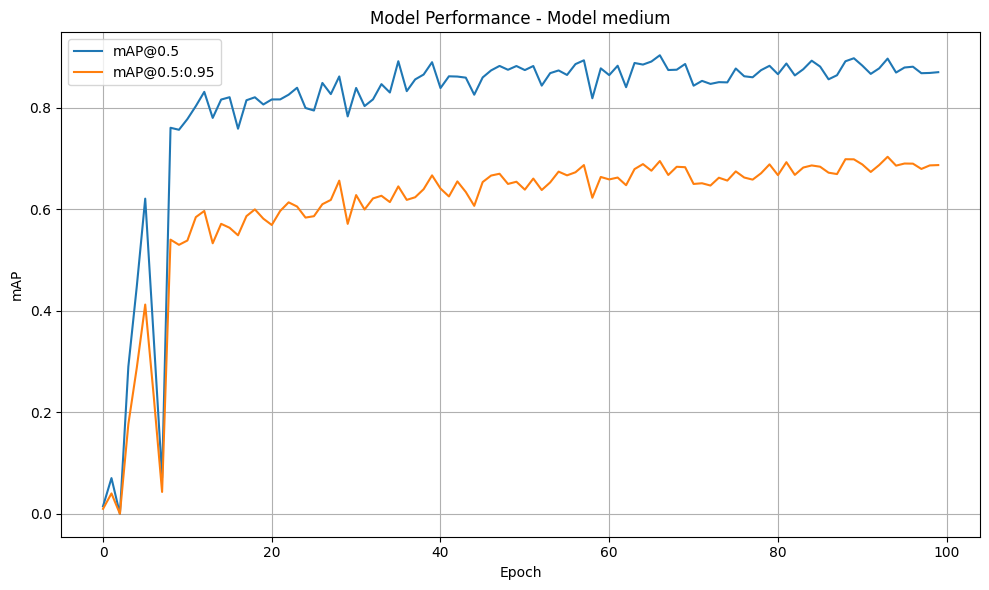

In [28]:
%matplotlib inline
for size in sizes:
    df = pd.read_csv(f"{project_base_segmentation_mask_lession}/training/{size}/results.csv")

    plt.figure(figsize=(10, 6))

    # Plot mAP50 dan mAP50-95
    plt.plot(df.index, df["metrics/mAP50(B)"], label="mAP@0.5")
    plt.plot(df.index, df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")

    # Tambahkan label dan judul
    plt.xlabel("Epoch")
    plt.ylabel("mAP")
    plt.title(f"Model Performance - Model {size}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Simpan plot
    graph_output_dir = f"{project_base_segmentation_mask_lession}/graph"
    os.makedirs(graph_output_dir, exist_ok=True)
    plt.savefig(os.path.join(graph_output_dir, f"mAP_comparison_{size}.png"))
    # plt.show()

## Training Object Detection Healthy Class

In [ ]:
# Variabel Global
models = ['yolo11n.pt', 'yolo11s.pt', 'yolo11m.pt']
sizes = ['nano', 'small', 'medium']
epochs = 100
batch = -1 # atau -1 untuk limitasi gpu 60%
data_path_objectDetection_leaf_class_only = "dataset/object_detection_leaf_class_only"
project_base_objectDetection_leaf_class_only = "results/object_detection_leaf_class_only"

In [ ]:
for model_name, size in zip(models, sizes):
    print(f"Training {size} model...")
    model = YOLO(model_name)

    start_time = time.time()
    training = model.train(
        data=f"{data_path_objectDetection_leaf_class_only}/data.yaml", 
        epochs=epochs, 
        imgsz=640, 
        batch=batch, 
        project=f"{project_base_objectDetection_leaf_class_only}/training", 
        name=f"{size}",
        exist_ok=True
    )

    measure_and_save_time(start_time, f"{project_base_objectDetection_leaf_class_only}/training/summary/time/{size}-train-time.txt")
    csv_filename = f"{project_base_objectDetection_leaf_class_only}/training/summary/{size}-training-metrics.csv"
    os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
    with open(csv_filename, "w") as f:
        f.write(training.to_csv())

    validation = model.val(
        data=f"{data_path_objectDetection_leaf_class_only}/data.yaml", 
        imgsz=640,
        project=f"{project_base_objectDetection_leaf_class_only}/validation",
        name=f"{size}",
        exist_ok=True,
        split="test"
    )

    csv_filename = f"{project_base_objectDetection_leaf_class_only}/validation/summary/{size}-validation-metrics.csv"
    os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
    with open(csv_filename, "w") as f:
        f.write(validation.to_csv())

    print(f"Finished training and validating {size} model.")

In [ ]:
for size in sizes:
    print(f"Running prediction for {size} model...")

    model = YOLO(f"results/object_detection_leaf_class_only/training/{size}/weights/best.pt")

    # Define the output directory for the current model size
    output_dir = f"results/object_detection_leaf_class_only/predict/{size}"
    os.makedirs(output_dir, exist_ok=True)

    results = model(
        source=f"{data_path_objectDetection_leaf_class_only}/test/images", 
        exist_ok=True,
        stream=True
    )

    for i, result in enumerate(results):
        original_filename = os.path.basename(result.path)
        save_path = os.path.join(output_dir, original_filename)
        result.save(filename=save_path)

    print(f"Finished predicting for {size} model.")

In [ ]:
%matplotlib inline
for size in sizes:
    df = pd.read_csv(f"{project_base_objectDetection_leaf_class_only}/training/{size}/results.csv")

    plt.figure(figsize=(10, 6))

    # Plot mAP50 dan mAP50-95
    plt.plot(df.index, df["metrics/mAP50(B)"], label="mAP@0.5")
    plt.plot(df.index, df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")

    # Tambahkan label dan judul
    plt.xlabel("Epoch")
    plt.ylabel("mAP")
    plt.title(f"Model Performance - Model {size}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Simpan plot
    graph_output_dir = f"{project_base_objectDetection_leaf_class_only}/graph"
    os.makedirs(graph_output_dir, exist_ok=True)
    plt.savefig(os.path.join(graph_output_dir, f"mAP_comparison_{size}.png"))
    plt.show()

## Fine Tune For Detect Rust, and Scab

In [ ]:
# Path sumber dataset YOLO
image_dir = Path("dataset/object_detection/train/images")
label_dir = Path("dataset/object_detection/train/labels")

# Path target few-shot
few_shot_base = Path("dataset/few_shot")

# Mapping class ID ke nama
class_map = {0: "frog-eye-leaf-spot", 1: "healthy", 2: "rust"}

# Buat index gambar per class berdasarkan nama file
class_to_files = defaultdict(list)
for img_file in sorted(image_dir.glob("*.jpg")):
    filename_lower = img_file.name.lower()
    if "frog-eye-leaf-spot" in filename_lower:
        cls = 0
    elif "healthy" in filename_lower:
        cls = 1
    elif "rust" in filename_lower:
        cls = 2
    else:
        continue  # Skip jika tidak dikenali

    label_file = label_dir / (img_file.stem + ".txt")
    if label_file.exists():
        class_to_files[cls].append((img_file, label_file))

# Generate few-shot data
for n in [5] + list(range(10, 51, 5)):
    target_image_dir = few_shot_base / f"{n}-shot" / "images"
    target_label_dir = few_shot_base / f"{n}-shot" / "labels"
    target_image_dir.mkdir(parents=True, exist_ok=True)
    target_label_dir.mkdir(parents=True, exist_ok=True)

    for cls in class_map:
        files = class_to_files[cls][:n]  # ambil berurutan
        for img_path, label_path in files:
            shutil.copy(img_path, target_image_dir / img_path.name)
            shutil.copy(label_path, target_label_dir / label_path.name)

# Copy data.yaml
shutil.copy("dataset/object_detection/data.yaml", "dataset/few_shot/data.yaml")

In [ ]:
# Variabel Global
models = {"nano": "results/object_detection_leaf_class_only/training/nano/weights/best.pt",
          "small": "results/object_detection_leaf_class_only/training/small/weights/best.pt",
          "medium": "results/object_detection_leaf_class_only/training/medium/weights/best.pt"}
sizes = ["nano", "small", "medium"]
shots = [5] + list(range(10, 51, 5))
size_to_shots = {
    "nano":   shots,
    "small":  shots,
    "medium": shots
}
epochs = 50
batch = -1 # atau -1 untuk limitasi gpu 60%
data_path_few_shot = "dataset/few_shot"
project_base_few_shot = "results/few_shot"

In [ ]:
for size in sizes:
    for shot in size_to_shots[size]:
        # 1. Load original YAML
        data_yaml_path = f"{data_path_few_shot}/data.yaml"
        with open(data_yaml_path, 'r') as f:
            data_yaml = yaml.safe_load(f)

        # 2. Ubah path train sesuai shot
        data_yaml['train'] = f"../{shot}-shot/images"
        data_yaml['test'] = f"../{shot}-shot/images"
        data_yaml['val'] = f"../{shot}-shot/images"

        # 3. Simpan YAML baru ke file sementara
        temp_yaml_path = f"{data_path_few_shot}/data-shot.yaml"
        with open(temp_yaml_path, 'w') as f:
            yaml.dump(data_yaml, f, sort_keys=False, default_flow_style=True)

        model = YOLO(models[size])
        start_time = time.time()
        training = model.train(
            data = temp_yaml_path,
            epochs = epochs,
            imgsz=640,
            batch=batch,
            project=f"{project_base_few_shot}/training",
            name=f"{size}/{shot}-shot",
            exist_ok=True,
            # patience=25,
            # freeze=8
        )

        measure_and_save_time(start_time, f"{project_base_few_shot}/training/summary/{size}/time/{shot}-shot-train-time.txt")
        csv_filename = f"{project_base_few_shot}/training/summary/{size}/{shot}-shot-training-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(training.to_csv())

        validation = model.val(
            data = temp_yaml_path,
            imgsz=640,
            project=f"{project_base_few_shot}/validation",
            name=f"{size}/{shot}-shot",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_few_shot}/validation/summary/{size}/{shot}-shot-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

In [ ]:
%matplotlib inline
for size in sizes:
    for shot in size_to_shots.get(size, shots):
        df = pd.read_csv(f"{project_base_few_shot}/training/{size}/{shot}-shot/results.csv")

        plt.figure(figsize=(10, 6))
        plt.plot(df.index, df["metrics/mAP50(B)"], label="mAP@0.5")
        plt.plot(df.index, df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
        plt.xlabel("Epoch")
        plt.ylabel("mAP")
        plt.title(f"Model Performance - {size} | {shot}-shot")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        graph_output_dir = f"{project_base_few_shot}/graph/{size}"
        os.makedirs(graph_output_dir, exist_ok=True)
        plt.savefig(os.path.join(graph_output_dir, f"mAP_comparison_{shot}-shot.png"))
        plt.show()

## Perbandingan Beberapa k-query Set vs n-shot

## Severity Estimation

### Creating GT for severity estimation

### SINGLE-STAGE (tanpa deteksi) — ambil SATU daun terbesar dari mask segmen

### SINGLE-STAGE (tanpa deteksi) — semua daun pada gambar

### MULTI-STAGE (deteksi ➜ crop ➜ segmen) — SATU daun (bbox terbesar)

### MULTI-STAGE (deteksi ➜ crop ➜ segmen) — SEMUA daun